In [1]:
# =============================================================================
# ANALISI OLIMPIADI — CLUSTERING SOCIOECONOMICO DEI PAESI
# =============================================================================
# Prerequisiti:
#   pip install pandas numpy scikit-learn matplotlib seaborn
#
# File necessari (nella stessa cartella di questo script):
#   - olympics_clean.csv   (il file che abbiamo pulito insieme)
# =============================================================================
# =============================================================================
# CLUSTERING GERARCHICO — PIL COME ASSE PRINCIPALE
# =============================================================================
# Approccio:
#   1. Prima dividiamo i paesi per fascia di PIL (soglie Banca Mondiale 2023)
#   2. Poi raffiniamo con K-means sugli altri indicatori all'interno di ogni fascia
#
# Vantaggi rispetto al K-means puro:
#   - Cluster economicamente interpretabili (segue la letteratura)
#   - Paesi anomali (PIL basso + urbanizzazione alta) restano nella fascia corretta
#   - Coerente con le classificazioni internazionali citate in tesi
#
# Soglie Banca Mondiale 2023 (PIL pro capite USD correnti):
#   < 1.136       → Basso reddito       (→ "Poveri estremi")
#   1.136–4.465   → Medio-basso reddito (→ "Reddito basso-medio")
#   4.466–13.845  → Medio-alto reddito  (→ "Reddito medio-alto")
#   > 13.845      → Alto reddito        (→ "Ricchi avanzati")
#
# File di input:  olympics_clean.csv
# File di output: olympics_with_clusters.csv  (sovrascrive il precedente)
# =============================================================================



# IMPORT
# -----------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

CLUSTER_ORDER = ['Ricchi avanzati', 'Reddito medio-alto',
                 'Reddito basso-medio', 'Poveri estremi']
CLUSTER_COLORS = {
    'Ricchi avanzati':     '#185FA5',
    'Reddito medio-alto':  '#3B6D11',
    'Reddito basso-medio': '#BA7517',
    'Poveri estremi':      '#A32D2D',
}

# Soglie Banca Mondiale 2023
WB_THRESHOLDS = {
    'Poveri estremi':     (0,      1136),
    'Reddito basso-medio':(1136,   4466),
    'Reddito medio-alto': (4466,  13846),
    'Ricchi avanzati':    (13846, np.inf),
}

In [14]:
#  CARICAMENTO E PREPARAZIONE
# -----------------------------------------------------------------------------
df = pd.read_csv('olympics_clean.csv')

SOCIO_VARS = ['gdp_per_capita', 'life_expectancy', 'urbanization_pct',
              'infant_mortality', 'primary_school_enrollment']

# Record più recente per paese (indicatori più aggiornati)
latest = (df[df[SOCIO_VARS].notna().sum(axis=1) >= 3]
          .sort_values('year')
          .groupby('noc').last().reset_index())

print(f"Paesi con dati sufficienti: {len(latest)}")
print(f"PIL pro capite disponibile: {latest['gdp_per_capita'].notna().sum()} paesi")




Paesi con dati sufficienti: 206
PIL pro capite disponibile: 205 paesi


In [15]:
#  STEP 1 — ASSEGNAZIONE FASCIA PIL (SOGLIE BANCA MONDIALE)
# -----------------------------------------------------------------------------
def assign_wb_group(gdp):
    """Assegna il cluster in base alle soglie Banca Mondiale 2023."""
    if pd.isna(gdp):
        return None  # gestito nel passo successivo
    for label, (low, high) in WB_THRESHOLDS.items():
        if low <= gdp < high:
            return label
    return 'Ricchi avanzati'

latest['cluster_wb'] = latest['gdp_per_capita'].apply(assign_wb_group)

# Per i paesi senza PIL: assegniamo con K-means sugli altri indicatori
# (li gestiamo nella sezione successiva)
print("\n=== DISTRIBUZIONE FASCE PIL ===")
print(latest['cluster_wb'].value_counts().reindex(CLUSTER_ORDER).to_string())
print(f"\nPaesi senza PIL (da assegnare con K-means): "
      f"{latest['cluster_wb'].isna().sum()}")


=== DISTRIBUZIONE FASCE PIL ===
cluster_wb
Ricchi avanzati        69
Reddito medio-alto     50
Reddito basso-medio    56
Poveri estremi         30

Paesi senza PIL (da assegnare con K-means): 1


In [16]:
#  STEP 2 — K-MEANS PER PAESI SENZA PIL
# -----------------------------------------------------------------------------
# I pochi paesi senza PIL vengono assegnati al cluster più vicino
# usando gli altri 4 indicatori

has_cluster = latest['cluster_wb'].notna()
missing_gdp = latest[~has_cluster].copy()

if len(missing_gdp) > 0:
    # Usiamo gli indicatori non-PIL come proxy
    proxy_vars = ['life_expectancy', 'urbanization_pct',
                  'infant_mortality', 'primary_school_enrollment']

    # Calcoliamo i centroidi dei cluster esistenti su questi indicatori
    centroids = (latest[has_cluster]
                 .groupby('cluster_wb')[proxy_vars]
                 .median())

    imp = SimpleImputer(strategy='median')
    scaler = StandardScaler()

    # Fit su tutti i paesi con cluster
    X_known = imp.fit_transform(latest[has_cluster][proxy_vars])
    X_known_sc = scaler.fit_transform(X_known)

    # Trasforma i paesi senza PIL
    X_unknown = imp.transform(missing_gdp[proxy_vars].fillna(
        latest[has_cluster][proxy_vars].median()
    ))
    X_unknown_sc = scaler.transform(X_unknown)

    # Centroidi scalati
    X_centroids = scaler.transform(imp.transform(centroids))

    # Assegna al centroide più vicino
    from sklearn.metrics.pairwise import euclidean_distances
    dist = euclidean_distances(X_unknown_sc, X_centroids)
    assigned = centroids.index[dist.argmin(axis=1)]
    latest.loc[~has_cluster, 'cluster_wb'] = assigned.values

    print(f"\nPaesi senza PIL assegnati con K-means:")
    print(latest[~has_cluster][['noc','country','cluster_wb']].to_string())



Paesi senza PIL assegnati con K-means:
     noc                                 country          cluster_wb
151  PRK  Korea, Democratic People's Republic of  Reddito medio-alto


In [17]:
#  RAFFINAMENTO CON GLI ALTRI INDICATORI (opzionale)
# -----------------------------------------------------------------------------
# All'interno di ogni fascia PIL, usiamo gli altri indicatori per verificare
# se ci sono sotto-gruppi — ma manteniamo le etichette originali.
# Questo step serve solo per l'analisi interna, non cambia i cluster finali.

print("\n=== COERENZA INTERNA DEI CLUSTER ===")
print("Verifica: gli indicatori non-PIL sono coerenti con la fascia?")
print()

for label in CLUSTER_ORDER:
    subset = latest[latest['cluster_wb'] == label]
    print(f"--- {label} ({len(subset)} paesi) ---")
    print(subset[SOCIO_VARS].median().round(1).to_string())
    print()


=== COERENZA INTERNA DEI CLUSTER ===
Verifica: gli indicatori non-PIL sono coerenti con la fascia?

--- Ricchi avanzati (69 paesi) ---
gdp_per_capita               33330.0
life_expectancy                 81.3
urbanization_pct                81.4
infant_mortality                 3.6
primary_school_enrollment      100.9

--- Reddito medio-alto (51 paesi) ---
gdp_per_capita               7354.1
life_expectancy                74.1
urbanization_pct               66.0
infant_mortality               12.9
primary_school_enrollment     101.6

--- Reddito basso-medio (56 paesi) ---
gdp_per_capita               2516.6
life_expectancy                69.8
urbanization_pct               50.8
infant_mortality               21.6
primary_school_enrollment     100.2

--- Poveri estremi (30 paesi) ---
gdp_per_capita               769.0
life_expectancy               61.5
urbanization_pct              34.1
infant_mortality              48.1
primary_school_enrollment     98.0



In [18]:
# ASSEGNAZIONE CLUSTER A TUTTO IL DATASET
# -----------------------------------------------------------------------------
# Usiamo il NOC come chiave per portare il cluster su tutte le edizioni

cluster_map = (latest[['noc', 'cluster_wb']]
               .rename(columns={'cluster_wb': 'cluster_label'})
               .drop_duplicates())

# Rimuoviamo il vecchio cluster_label dal dataset e rimettiamo il nuovo
df_new = df.drop(columns=['cluster_label'], errors='ignore')
df_merged = df_new.merge(cluster_map, on='noc', how='left')

# Aggiungiamo anche il numero di cluster (per compatibilità con altri notebook)
cluster_num_map = {
    'Ricchi avanzati': 2,
    'Reddito medio-alto': 0,
    'Reddito basso-medio': 1,
    'Poveri estremi': 3,
}
df_merged['cluster'] = df_merged['cluster_label'].map(cluster_num_map)

print(f"Dataset finale: {len(df_merged):,} righe")
print(f"Paesi con cluster assegnato: {df_merged['cluster_label'].notna().sum():,}")
print()
print("=== DISTRIBUZIONE CLUSTER NEL DATASET FINALE ===")
print(df_merged['cluster_label'].value_counts().reindex(CLUSTER_ORDER).to_string())

Dataset finale: 3,368 righe
Paesi con cluster assegnato: 3,090

=== DISTRIBUZIONE CLUSTER NEL DATASET FINALE ===
cluster_label
Ricchi avanzati        1035
Reddito medio-alto      765
Reddito basso-medio     840
Poveri estremi          450


In [19]:
#  VERIFICA — PAESI PRIMA ANOMALI
# -----------------------------------------------------------------------------
print("\n=== VERIFICA PAESI PRIMA ANOMALI ===")
check = ['COG', 'MRT', 'GAB', 'AGO', 'CMR', 'GHA']
check_latest = latest[latest['noc'].isin(check)][
    ['noc', 'country', 'gdp_per_capita', 'cluster_wb']
].sort_values('gdp_per_capita')
print(check_latest.to_string())


=== VERIFICA PAESI PRIMA ANOMALI ===
     noc     country  gdp_per_capita           cluster_wb
37   CMR    Cameroon     1525.933178  Reddito basso-medio
128  MRT  Mauritania     1667.694442  Reddito basso-medio
67   GHA       Ghana     2076.686607  Reddito basso-medio
39   COG       Congo     2371.899796  Reddito basso-medio
2    AGO      Angola     2549.076496  Reddito basso-medio
63   GAB       Gabon     7166.064985   Reddito medio-alto


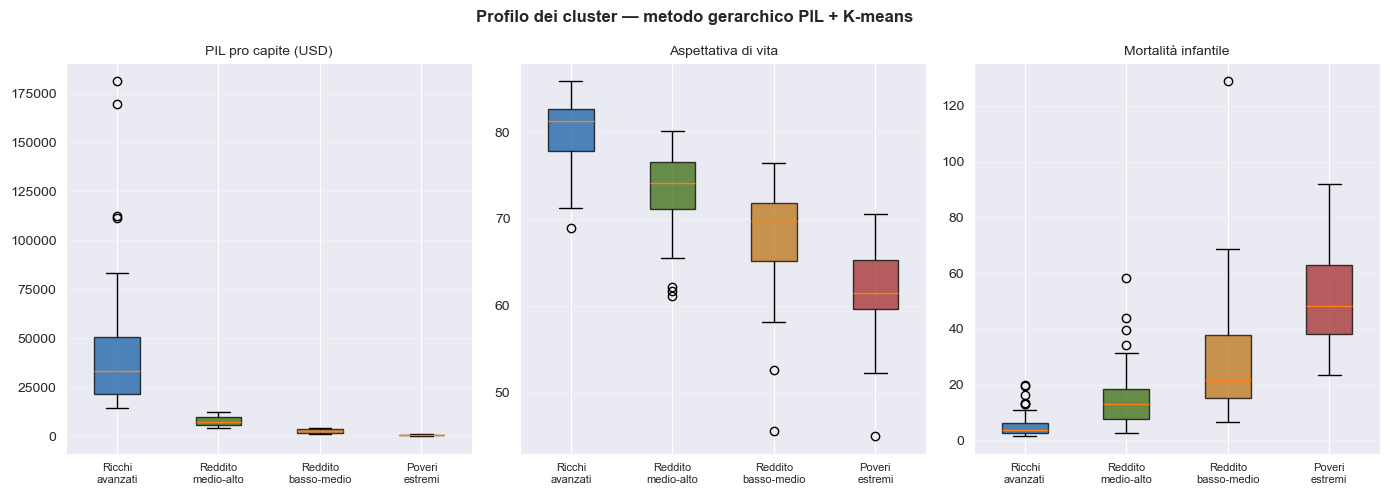

✓ Salvato: cluster_profiles_hierarchical.png


In [20]:
#  VISUALIZZAZIONE PROFILI CLUSTER
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

vars_plot = [
    ('gdp_per_capita',   'PIL pro capite (USD)'),
    ('life_expectancy',  'Aspettativa di vita'),
    ('infant_mortality', 'Mortalità infantile'),
]

for ax, (var, title) in zip(axes, vars_plot):
    data = [latest[latest['cluster_wb'] == label][var].dropna().values
            for label in CLUSTER_ORDER]
    colors = [CLUSTER_COLORS[l] for l in CLUSTER_ORDER]
    bp = ax.boxplot(data, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticklabels([l.replace(' ', '\n') for l in CLUSTER_ORDER], fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Profilo dei cluster — metodo gerarchico PIL + K-means',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_profiles_hierarchical.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: cluster_profiles_hierarchical.png")


La classificazione dei paesi in cluster socioeconomici segue
un approccio gerarchico in due stadi:

STADIO 1 — Soglie Banca Mondiale (2023):
  I paesi vengono prima assegnati a quattro fasce di reddito
  in base al PIL pro capite (USD correnti):
  • Alto reddito:        > $13.845  → "Ricchi avanzati"
  • Medio-alto reddito:  $4.466–$13.845 → "Reddito medio-alto"
  • Medio-basso reddito: $1.136–$4.465  → "Reddito basso-medio"
  • Basso reddito:       < $1.136   → "Poveri estremi"

  Fonte: World Bank Country and Lending Groups, 2023.
  (https://datahelpdesk.worldbank.org/knowledgebase/articles/906519)

STADIO 2 — K-means per paesi senza PIL:
  I paesi privi di dati PIL vengono assegnati al cluster più
  vicino per distanza euclidea sui quattro indicatori proxy
  (aspettativa di vita, urbanizzazione, mortalità infantile,
  iscrizione scolastica), normalizzati con z-score.

Questo approccio garantisce:
  1. Coerenza con le classificazioni internazionali standard
  2. Interpretabilità economica dei cluster
  3. Robustezza rispetto agli outlier su indicatori secondari
     (es. paesi con alta urbanizzazione ma PIL basso)
""")


In [21]:
#  SALVATAGGIO
# -----------------------------------------------------------------------------
df_merged.to_csv('olympics_with_clusters.csv', index=False)
print("✓ Salvato: olympics_with_clusters.csv")
print("  → tutti i notebook successivi useranno automaticamente i nuovi cluster")


✓ Salvato: olympics_with_clusters.csv
  → tutti i notebook successivi useranno automaticamente i nuovi cluster


In [22]:
df.head()

,edition,year,country,noc,gold,silver,bronze,total_medals,host_country_code,host_city,...,population,pop_density,primary_school_enrollment,infant_mortality,gdp_total,medals_per_million,gold_per_million,medals_per_gdp_bn,won_medal,hdi
0,1964 Summer Olympics,1964,United States,USA,36,26,28,90,JPN,Tokyo,...,1.850355e+08,20.361518,NaN,25.200,5.861570e+11,0.4864,0.1946,0.1535,1,NaN
1,1964 Summer Olympics,1964,Soviet Union,RUS,30,31,35,96,JPN,Tokyo,...,1.219210e+08,NaN,NaN,32.975,NaN,0.7874,0.2461,NaN,1,NaN
2,1964 Summer Olympics,1964,Japan,JPN,16,5,8,29,JPN,Tokyo,...,9.452600e+07,258.965549,NaN,26.700,6.101328e+10,0.3068,0.1693,0.4753,1,NaN
3,1964 Summer Olympics,1964,Germany,GER,10,22,18,50,JPN,Tokyo,...,7.373317e+07,212.067872,NaN,NaN,9.982650e+10,0.6781,0.1356,0.5009,1,NaN
4,1964 Summer Olympics,1964,Italy,ITA,10,10,7,27,JPN,Tokyo,...,5.071688e+07,173.028005,NaN,41.700,5.027793e+10,0.5324,0.1972,0.5370,1,NaN


In [23]:
# -----------------------------------------------------------------------------
print("\n=== ANTEPRIMA DATASET FINALE ===")
cols_preview = ['country', 'year', 'total_medals', 'gdp_per_capita', 'cluster_label']
print(df_merged[cols_preview].dropna(subset=['cluster_label']).head(10).to_string(index=False))


=== ANTEPRIMA DATASET FINALE ===
      country  year  total_medals  gdp_per_capita      cluster_label
United States  1964            90     3165.352148    Ricchi avanzati
 Soviet Union  1964            96             NaN Reddito medio-alto
        Japan  1964            29      644.431248    Ricchi avanzati
      Germany  1964            50     1352.676508    Ricchi avanzati
        Italy  1964            27      990.384650    Ricchi avanzati
      Hungary  1964            22             NaN    Ricchi avanzati
       Poland  1964            23             NaN    Ricchi avanzati
    Australia  1964            18     1880.413688    Ricchi avanzati
Great Britain  1964            18     1502.303313    Ricchi avanzati
      Finland  1964             5     1374.619673    Ricchi avanzati
